# Ligand-Receptor Experiment

Two-population simulation with fast ligands, slow receptors, type-specific spot widths, and simple binding/unbinding dynamics.

In [32]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2


## I. Simulation of the receptors and ligands interactions

In [33]:
simulation_config = {
    "n_ligands": 10,
    "n_receptors": 5,
    "nframes": 50,
    "nposframe": 3,
    "dt": 1.0,
    "ligand_D": [(3.0, 0.65), (6.0, 0.35)],
    "receptor_D": [(0.0, 0.75), (0.05, 0.25)],
    "frame_size": (128, 128),
    "boundary_margin": 10,
    "binding_radius": 6.0,
    "kon": 2.0,
    "koff": 0.05,
    "allow_multiple_ligands_per_receptor": False,
    "bound_position_noise": 0.15,
    "ligand_intensity_mean": 750,
    "ligand_intensity_std": 100,
    "receptor_intensity_mean": 750,
    "receptor_intensity_std": 150,
    "ligand_sigma_mean": 0.75,
    "ligand_sigma_std": 0.08,
    "receptor_sigma_mean": 1.35,
    "receptor_sigma_std": 0.12,
}

image_config = {
    "particle_intensity": [700, 300],
    "particle_sigma": [1.0, 0.2],
    "particle_type_props": {
        "ligand": {
            "particle_intensity": [750, 100],
            "particle_sigma": [0.75, 0.08],
        },
        "receptor": {
            "particle_intensity": [750, 150],
            "particle_sigma": [1.35, 0.12],
        },
    },
    "use_trajectory_sigma": True,
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = LigandReceptorSimulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR
trajectories_GT = sim.trajectories_GT
ligands_GT = sim.get_ligands()
receptors_GT = sim.get_receptors()
binding_events = sim.binding_events
video_ligand_receptor = sim.video

In [34]:
print(f"Ligands: {len(ligands_GT)}")
print(f"Receptors: {len(receptors_GT)}")
print(f"Binding events: {len(binding_events)}")

if binding_events:
    durations = [event["end_subframe"] - event["start_subframe"] + 1 for event in binding_events]
    print(f"Mean bound duration: {np.mean(durations):.2f} subframes")
    print(binding_events[:5])

Ligands: 10
Receptors: 5
Binding events: 7
Mean bound duration: 38.71 subframes
[{'ligand_id': 13, 'receptor_id': 3, 'start_subframe': 0, 'end_subframe': 38, 'start_frame': 0, 'end_frame': 12}, {'ligand_id': 6, 'receptor_id': 0, 'start_subframe': 25, 'end_subframe': 97, 'start_frame': 8, 'end_frame': 32}, {'ligand_id': 13, 'receptor_id': 3, 'start_subframe': 41, 'end_subframe': 44, 'start_frame': 13, 'end_frame': 14}, {'ligand_id': 13, 'receptor_id': 3, 'start_subframe': 47, 'end_subframe': 115, 'start_frame': 15, 'end_frame': 38}, {'ligand_id': 10, 'receptor_id': 0, 'start_subframe': 98, 'end_subframe': 128, 'start_frame': 32, 'end_frame': 42}]


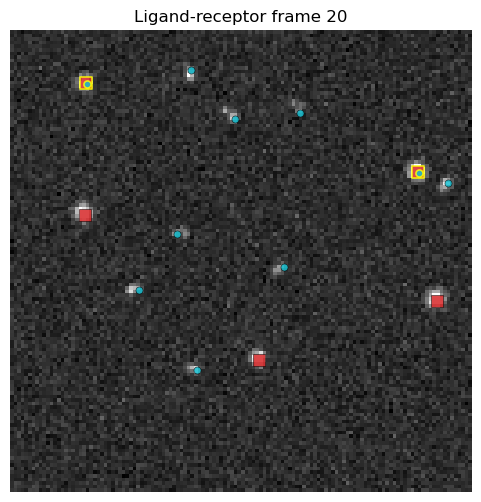

In [35]:
def plot_ligand_receptor_frame(sim, frame_id=0, show_ids=False):
    fig, ax = plt.subplots(figsize=(6, 6))
    vmax = np.percentile(sim.frames, 99.8)
    ax.imshow(sim.frames[frame_id], cmap="gray", vmin=0, vmax=vmax)

    for traj in sim.trajectories_GT:
        pos = traj.get_position_at_frame(frame_id)
        if pos is None:
            continue

        row, col = pos
        is_receptor = traj.particle_type == "receptor"
        is_bound = traj.get_state_at_frame(frame_id) == "bound"

        ax.scatter(
            col,
            row,
            s=75 if is_receptor else 26,
            c="tab:red" if is_receptor else "tab:cyan",
            marker="s" if is_receptor else "o",
            edgecolors="yellow" if is_bound else "black",
            linewidths=1.2 if is_bound else 0.4,
            alpha=0.85,
        )

        if show_ids:
            ax.text(col + 1, row + 1, str(traj.id), color="white", fontsize=8)

    ax.set_title(f"Ligand-receptor frame {frame_id}")
    ax.axis("off")
    plt.show()


plot_ligand_receptor_frame(sim, frame_id=20, show_ids=False)

In [36]:
sim.animate(interval=100, vmax=np.percentile(frames, 99.8))

## II. Application of the masked tracking pipeline

In [42]:
# tracking only immobile particles, that is within 2 pixels moving distance
loc_results = sim.track(
    mode="localization",
    detection_threshold=400,
    max_distance=2, # only static
    min_length=5,
    cost_func_peak2peak=None,
    cost_func_traj2traj=None
)
print(f"Found {len(loc_results[0])} static particles.")

static_trajs_loc_sep = loc_results[0]

# now extract all peaks
peaks_for_tracking_sep = extract_peaks(
                        frames, 
                        mode='localization', 
                        detection_threshold=400, 
                        r_squared_threshold=0.5, 
                        verbose_loc=False, 
                        visualization_loc=False
                     )

print(f"Extracted {len(peaks_for_tracking_sep)} peaks for tracking (including both mobile and immobile particles).")

# remove peaks corresponding to static trajectories
mobile_peaks_for_tracking_sep = remove_static_peaks(peaks_for_tracking_sep, static_trajs_loc_sep, tolerance=5.0, verbose=True)


# track with regular pipeline on the remaining mobile trajectories
trajs_loc_sep, cost_peak2peak_sep, assignment_output_sep, cost_traj2traj_sep = track_from_peaks(mobile_peaks_for_tracking_sep,
                                                                                                            trajectories_GT, 
                                                                                                            max_distance=10, 
                                                                                                            min_length=5, 
                                                                                                            algo_peak2peak="hungarian", 
                                                                                                            cost_func_peak2peak=None, 
                                                                                                            algo_traj2traj="hungarian", 
                                                                                                            cost_func_traj2traj=None, 
                                                                                                            verbose_assignment=False)
# print number of mobile trajectories found
print(f"Found {len(trajs_loc_sep)} mobile trajectories.")

# add back the static trajectories to the mobile ones to have the full set of trajectories for evaluation
trajs_loc_sep += static_trajs_loc_sep

Found 7 static particles.
Extracted 50 peaks for tracking (including both mobile and immobile particles).
Removed 50 peaks from static trajectory 3 (length 50, frames 0–49)
Removed 50 peaks from static trajectory 2 (length 50, frames 0–49)
Removed 50 peaks from static trajectory 0 (length 50, frames 0–49)
Removed 50 peaks from static trajectory 4 (length 50, frames 0–49)
Removed 28 peaks from static trajectory 10 (length 28, frames 0–27)
Removed 7 peaks from static trajectory 1 (length 7, frames 27–33)
Removed 17 peaks from static trajectory 6 (length 17, frames 33–49)
Found 10 mobile trajectories.


In [43]:
trajs_loc_sep, min_cost, assignment = assign_trajectories(trajs_loc_sep, trajectories_GT, cost_function = None, verbose=True)

Computing assignment using algorithm: hungarian
0 -> 12
1 -> 10
2 -> 5
3 -> 9
4 -> 11
5 -> 6
6 -> 7
7 -> 8
8 -> 14
9 -> 13
10 -> 3
11 -> 2
12 -> 0
13 -> 4
14 -> -1
15 -> 1
16 -> -1
Trajectory ID: 12, Frames: 0->8, Number of positions: 9, Relabelled: Yes
Trajectory ID: 10, Frames: 2->8, Number of positions: 7, Relabelled: Yes
Trajectory ID: 5, Frames: 7->11, Number of positions: 5, Relabelled: Yes
Trajectory ID: 9, Frames: 17->23, Number of positions: 7, Relabelled: Yes
Trajectory ID: 11, Frames: 17->23, Number of positions: 7, Relabelled: Yes
Trajectory ID: 6, Frames: 23->33, Number of positions: 11, Relabelled: Yes
Trajectory ID: 7, Frames: 28->34, Number of positions: 7, Relabelled: Yes
Trajectory ID: 8, Frames: 38->42, Number of positions: 5, Relabelled: Yes
Trajectory ID: 14, Frames: 38->46, Number of positions: 9, Relabelled: Yes
Trajectory ID: 13, Frames: 44->49, Number of positions: 6, Relabelled: Yes
Trajectory ID: 3, Frames: 0->49, Number of positions: 50, Relabelled: Yes
Traj

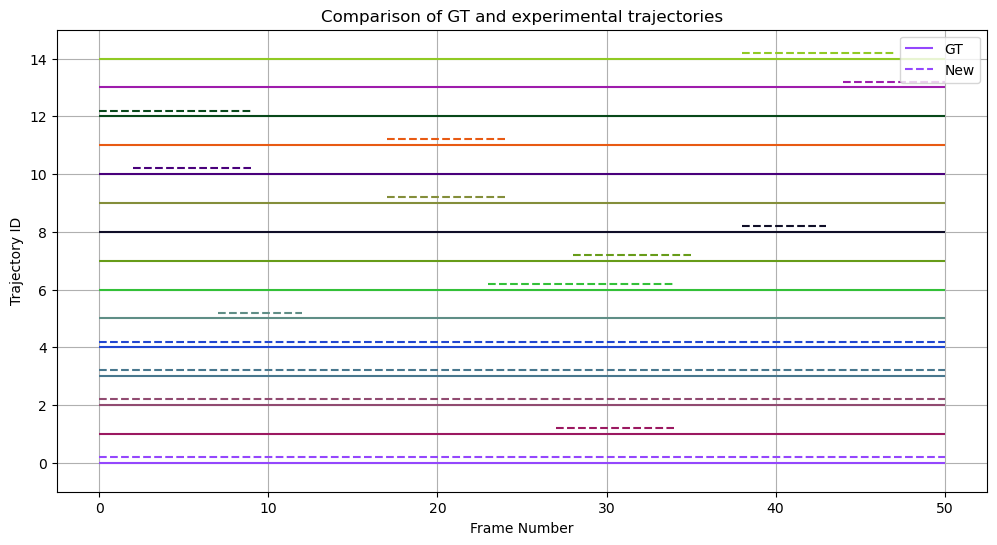

In [44]:
linear_trajectories_visualizer(trajs_loc_sep, trajectories_GT)

In [45]:
# the the true GT immobile particles (receptors)
print("True immobile particles (receptors):")
for traj in trajectories_GT:
    if traj.particle_type == "receptor":
        print(f"Receptor ID {traj.id} at position {traj.get_position_at_frame(0)}")

True immobile particles (receptors):
Receptor ID 0 at position (38.944654284368255, 112.67714509227095)
Receptor ID 1 at position (73.43729089356594, 116.97455533607271)
Receptor ID 2 at position (90.8057016380491, 68.61423988154039)
Receptor ID 3 at position (16.779323378463275, 21.07105062299336)
Receptor ID 4 at position (50.62319293493012, 20.317813894144162)


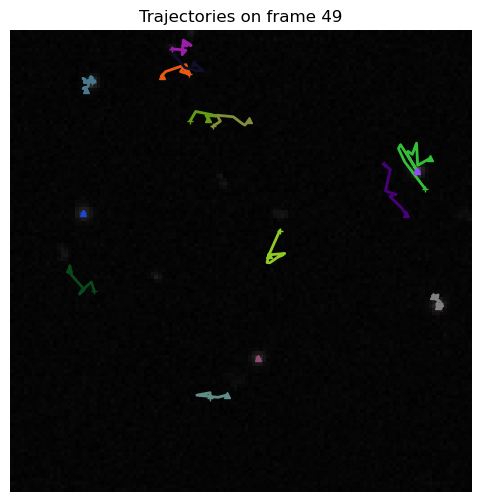

In [46]:
show_trajectories(frames,trajs_loc_sep, frame_id=simulation_config["nframes"]-1)